In [1]:
import os
import random
import time
from pathlib import Path


import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms
from PIL import Image


from scipy.io import loadmat
from sklearn.model_selection import train_test_split
from sklearn.utils import shuffle
from tqdm import tqdm

# ----------------------
# Device
# ----------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device, torch.cuda.get_device_name(0) if device.type == "cuda" else "")



Device: cuda NVIDIA GeForce RTX 3060 Laptop GPU


In [2]:
def prepare_mnist_with_grey_dots_cpu(
    mat_path,
    class_ratio=0.5,
    split_ratios={'train': 0.7, 'val': 0.15, 'test': 0.15},
    seed=42,
    dot_params=None
):
    np.random.seed(seed)

    # --- Load data ---
    data = loadmat(mat_path)
    X = data['data'].T  # (n_samples, 784)
    y = data['label'].flatten()

    # --- Reduce dataset size by class ---
    X_subset, y_subset = [], []
    for cls in np.unique(y):
        idx = np.where(y == cls)[0]
        n_select = int(len(idx) * class_ratio)
        selected_idx = np.random.choice(idx, n_select, replace=False)
        X_subset.append(X[selected_idx])
        y_subset.append(y[selected_idx])
    X = np.concatenate(X_subset)
    y = np.concatenate(y_subset)

    # --- Shuffle ---
    X, y = shuffle(X, y, random_state=seed)

    # --- Stratified split ---
    train_ratio = split_ratios['train']
    val_ratio = split_ratios['val'] / (split_ratios['val'] + split_ratios['test'])

    X_train, X_rest, y_train, y_rest = train_test_split(
        X, y, train_size=train_ratio, stratify=y, random_state=seed)
    X_val, X_test, y_val, y_test = train_test_split(
        X_rest, y_rest, train_size=val_ratio, stratify=y_rest, random_state=seed)

    # --- Add grey dots + record their positions ---
    def add_grey_dots_np(X_np):
        X_mod = X_np.copy().reshape(-1, 28, 28)
        N = X_mod.shape[0]
        dot_locations = []

        # Convert image to strict black-and-white
        X_strict = np.where(X_mod > 50, 255, 0).astype(np.uint8)
        bright_pixels = [np.argwhere(img == 255) for img in X_strict]

        for i in range(N):
            coords = bright_pixels[i]
            if coords.size == 0:
                dot_locations.append(None)
                continue

            # --- Location ---
            if dot_params and dot_params.get('location') is not None:
                y_dot, x_dot = dot_params['location']
            else:
                y_dot, x_dot = coords[np.random.randint(len(coords))]

            # --- Radius (size) ---
            if dot_params and dot_params.get('radius') is not None:
                radius = int(dot_params['radius'])
            else:
                radius = np.random.randint(1, 3)

            # --- Intensity ---
            if dot_params and dot_params.get('gray') is not None:
                gray = int(dot_params['gray'])
            else:
                gray = np.random.randint(100, 181)

            # --- Apply circular grey dot ---
            y_min = max(y_dot - radius, 0)
            y_max = min(y_dot + radius, 27)
            x_min = max(x_dot - radius, 0)
            x_max = min(x_dot + radius, 27)

            ys, xs = np.ogrid[y_min:y_max+1, x_min:x_max+1]
            dist_sq = (ys - y_dot)**2 + (xs - x_dot)**2
            mask = dist_sq <= radius**2

            X_mod[i, y_min:y_max+1, x_min:x_max+1][mask] = gray

            # Save location
            dot_locations.append({
                'y': int(y_dot),
                'x': int(x_dot),
                'radius': int(radius),
                'gray': int(gray)
            })

        return X_mod.reshape(-1, 784).astype(np.uint8), dot_locations
    # --- Save original images before modifying ---
    X_train_orig = X_train.copy()
    X_val_orig   = X_val.copy()
    X_test_orig  = X_test.copy()
    # Apply grey dot addition
    X_train, dots_train = add_grey_dots_np(X_train)
    X_val, dots_val = add_grey_dots_np(X_val)
    X_test, dots_test = add_grey_dots_np(X_test)

    # Return dictionary with original images added
    return {
        'train': {'X': X_train, 'X_orig': X_train_orig, 'y': y_train, 'dots': dots_train},
        'val':   {'X': X_val,   'X_orig': X_val_orig,   'y': y_val,   'dots': dots_val},
        'test':  {'X': X_test,  'X_orig': X_test_orig,  'y': y_test,  'dots': dots_test}
    }


In [3]:
class InMemoryMNISTDataset(Dataset):
    def __init__(self, X, y, dots=None, X_orig=None, transform=None,
                 return_dot_info=False, return_index=False, return_orig=False):
        self.X = X
        self.y = y
        self.dots = dots
        self.X_orig = X_orig
        self.transform = transform
        self.return_dot_info = return_dot_info
        self.return_index = return_index
        self.return_orig = return_orig

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        image = self.X[idx]
        label = self.y[idx]

        # --- Original image ---
        image_orig = self.X_orig[idx] if self.X_orig is not None else None

        # --- Ensure shape ---
        if image.ndim == 1:
            image = image.reshape(28, 28)
        if image_orig is not None and image_orig.ndim == 1:
            image_orig = image_orig.reshape(28, 28)

        # --- Convert to PIL ---
        image = transforms.functional.to_pil_image(image)
        if image_orig is not None:
            image_orig = transforms.functional.to_pil_image(image_orig)

        if self.transform:
            image = self.transform(image)
            if image_orig is not None:
                # Optionally transform original the same way
                image_orig = self.transform(image_orig)

        # --- Build output tuple ---
        out = [image, label]
        if self.return_orig and image_orig is not None:
            out.append(image_orig)
        if self.return_dot_info and self.dots is not None:
            out.append(self.dots[idx])
        if self.return_index:
            out.append(idx)

        return tuple(out)


In [4]:
# ============================================
# Load MNIST with optional grey dot anomalies
# ============================================
splits = prepare_mnist_with_grey_dots_cpu(
    mat_path="/home/blayne/mnist-original.mat",
    class_ratio=0.7,
    split_ratios={'train': 0.7, 'val': 0.15, 'test': 0.15},
    seed=42
)

# ============================================
# Define transforms
# ============================================
base_transform = transforms.Compose([
    #transforms.RandomRotation(15),
    #transforms.RandomAffine(0, translate=(0.1, 0.1)),
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
    #transforms.Normalize(mean=[0.5], std=[0.5])
])

# ============================================
# Wrap into PyTorch Datasets (with original images)
# ============================================

train_dataset = InMemoryMNISTDataset(
    X=splits['train']['X'],
    X_orig=splits['train']['X_orig'],      # <-- original images
    y=splits['train']['y'],
    dots=splits['train']['dots'],
    transform=base_transform,
    return_dot_info=True,
    return_index=True,
    return_orig=True                        # <-- return original image
)

val_dataset = InMemoryMNISTDataset(
    X=splits['val']['X'],
    X_orig=splits['val']['X_orig'],
    y=splits['val']['y'],
    dots=splits['val']['dots'],
    transform=base_transform,
    return_dot_info=True,
    return_index=True,
    return_orig=True
)

test_dataset = InMemoryMNISTDataset(
    X=splits['test']['X'],
    X_orig=splits['test']['X_orig'],
    y=splits['test']['y'],
    dots=splits['test']['dots'],
    transform=base_transform,
    return_dot_info=True,
    return_index=True,
    return_orig=True
)

# ============================================
# Optimized DataLoaders
# ============================================

train_loader = DataLoader(
    train_dataset, batch_size=28, shuffle=True,
    num_workers=6, pin_memory=True, persistent_workers=True
)

val_loader = DataLoader(
    val_dataset, batch_size=28, shuffle=False,
    num_workers=6, pin_memory=True, persistent_workers=True
)

test_loader = DataLoader(
    test_dataset, batch_size=28, shuffle=False,
    num_workers=4, pin_memory=False, persistent_workers=False
)

print(f"Train: {len(train_dataset)}, Val: {len(val_dataset)}, Test: {len(test_dataset)}")


Train: 34297, Val: 7349, Test: 7350


In [5]:
def show_sample_images_pair(dataset, num_samples=10):
    """
    Display paired samples from a dataset that returns both (modified, original).

    Top row: modified images (with grey dots)
    Bottom row: original MNIST images
    """
    indices = random.sample(range(len(dataset)), num_samples)
    plt.figure(figsize=(15, 4))

    for i, idx in enumerate(indices):
        sample = dataset[idx]

        # --- Unpack modified image and label ---
        image_mod = sample[0]      # modified image (with grey dot)
        label = sample[1]

        # --- Extract original image ---
        image_orig = None
        if len(sample) > 2:
            # Case 1: X_orig stored as a dict
            if isinstance(sample[2], dict) and 'X_orig' in sample[2]:
                image_orig = sample[2]['X_orig']
            else:
                image_orig = sample[2]

        # --- Convert modified image to numpy ---
        if isinstance(image_mod, Image.Image):
            image_mod = np.array(image_mod).astype(np.float32) / 255.0
        elif isinstance(image_mod, torch.Tensor):
            image_mod = image_mod.squeeze().cpu().numpy()

        # --- Convert original image to numpy ---
        if image_orig is not None:
            if isinstance(image_orig, Image.Image):
                image_orig = np.array(image_orig).astype(np.float32) / 255.0
            elif isinstance(image_orig, torch.Tensor):
                image_orig = image_orig.squeeze().cpu().numpy()
            elif isinstance(image_orig, np.ndarray):
                image_orig = image_orig.astype(np.float32)
            else:
                # fallback: convert to array if possible
                try:
                    image_orig = np.array(image_orig).astype(np.float32)
                except:
                    raise TypeError(f"Unsupported type for original image: {type(image_orig)}")

        # --- Plot modified (top row) ---
        plt.subplot(2, num_samples, i + 1)
        plt.imshow(image_mod, cmap='gray', vmin=0, vmax=1)
        plt.title(f"Modified {idx}")
        plt.axis("off")

        # --- Plot original (bottom row) ---
        if image_orig is not None:
            plt.subplot(2, num_samples, i + 1 + num_samples)
            plt.imshow(image_orig, cmap='gray', vmin=0, vmax=1)
            plt.title(f"Original {idx}")
            plt.axis("off")

    plt.tight_layout()
    plt.show()


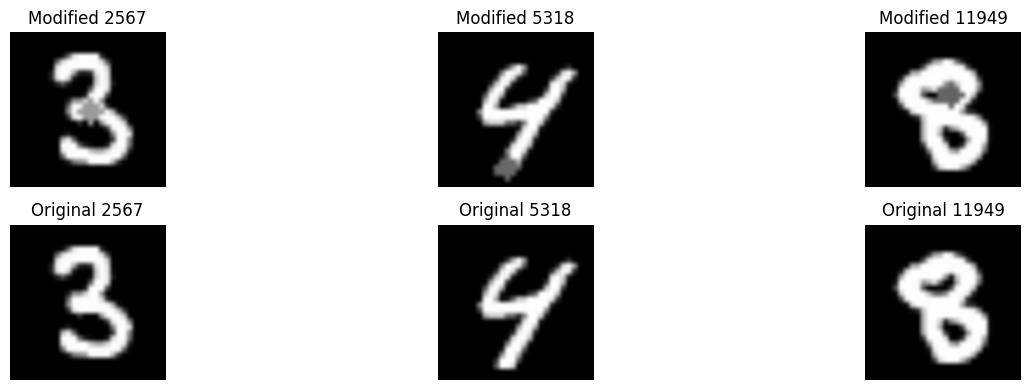

In [6]:
show_sample_images_pair(train_dataset, num_samples=3)
# Example usage:


In [7]:
def show_sample_images_2(dataset, num_samples=10, title='Modified Images'):
    plt.figure(figsize=(num_samples * 1.5, 2))
    indices = torch.randperm(len(dataset))[:num_samples]

    for i, idx in enumerate(indices):
        sample = dataset[idx]

        # Defensive unpacking
        img = sample[0]
        label = sample[1]
        image_orig = sample[2] if len(sample) > 2 else None
        dot_info = sample[3] if len(sample) > 3 else None
        sample_idx = sample[4] if len(sample) > 4 else None

        if isinstance(img, torch.Tensor):
            img = img.squeeze().numpy()

        plt.subplot(1, num_samples, i + 1)
        plt.imshow(img, cmap='gray')

        # Overlay the anomaly location (scaled)
        if dot_info is not None:
            scale = img.shape[0] / 28  # dynamic scale
            y = dot_info['y'] * scale
            x = dot_info['x'] * scale
            radius = dot_info['radius'] * scale / 2
            plt.scatter(x, y, s=(radius * 8)**2, edgecolor='red', facecolor='none', linewidths=1.5)

        plt.axis('off')
        plt.title(str(int(label)), fontsize=10)

    plt.suptitle(title)
    plt.tight_layout()
    plt.show()

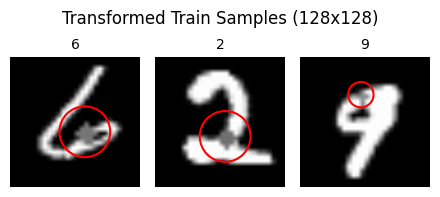

In [8]:
show_sample_images_2(train_dataset, num_samples=3, title="Transformed Train Samples (128x128)")

In [9]:
def random_mask_v5_opt1(
    x, 
    grey_dot_coords=None,
    mask_ratio=0.5,      
    patch_size=8, 
    block_size=3,      
    threshold=0.01, 
    dot_space='28',     # <---- new
    debug=False
):
    B, C, H, W = x.shape
    masks = torch.ones_like(x)
    n_h, n_w = H // patch_size, W // patch_size

    for b in range(B):
        # --- Use stored grey dot info if available ---
        if grey_dot_coords is not None and b < len(grey_dot_coords) and grey_dot_coords[b] is not None:
            info = grey_dot_coords[b]
            y_dot = info.get('y', None)
            x_dot = info.get('x', None)
            radius = info.get('radius', 2)

            # --- Convert to scalar if needed ---
            def to_scalar(val):
                if isinstance(val, (np.ndarray, torch.Tensor)):
                    return int(val.flatten()[0])
                else:
                    return int(val)
            y_dot = to_scalar(y_dot)
            x_dot = to_scalar(x_dot)
            radius = to_scalar(radius)
        else:
            # fallback: random patch
            y_dot = np.random.randint(H)
            x_dot = np.random.randint(W)
            radius = 2

        # --- Scale coordinates only if they’re from 28x28 space ---
        if dot_space == '28':
            scale = H / 28
            y_dot = int(y_dot * scale)
            x_dot = int(x_dot * scale)

        # --- Mask patch block around dot ---
        patch_y = y_dot // patch_size
        patch_x = x_dot // patch_size
        half_block = block_size // 2
        start_y = max(0, patch_y - half_block)
        end_y = min(n_h, patch_y + half_block + 1)
        start_x = max(0, patch_x - half_block)
        end_x = min(n_w, patch_x + half_block + 1)
        
        h_start, h_end = start_y * patch_size, end_y * patch_size
        w_start, w_end = start_x * patch_size, end_x * patch_size

        masks[b, :, h_start:h_end, w_start:w_end] = 0

        if debug:
            print(f"[Batch {b}] dot=({y_dot},{x_dot}), mask block y=({h_start}:{h_end}), x=({w_start}:{w_end})")

    return x * masks, masks


In [10]:
def show_sample_with_mask(dataset, mask_fn, num_samples=5, patch_size=16, title="Masked Images", debug=False):
    """
    Display images from the dataset with a mask applied around grey-dot anomalies.

    Args:
        dataset: InMemoryMNISTDataset instance
        mask_fn: function(x, grey_dot_coords, patch_size, debug) -> masked_x, mask
        num_samples: number of images to display
        patch_size: size of the square patch to mask
        title: figure title
        debug: if True, print debug info from mask_fn
    """
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    plt.figure(figsize=(num_samples * 3, 3))

    indices = torch.randperm(len(dataset))[:num_samples]

    for i, idx in enumerate(indices):
        sample = dataset[idx]

        # --- Unpack sample ---
        img        = sample[0]
        label      = sample[1]
        dot_info   = sample[3] if len(sample) > 3 else None

        # --- Convert to tensor with batch dimension ---
        if isinstance(img, np.ndarray):
            img_tensor = torch.tensor(img, dtype=torch.float32).unsqueeze(0).unsqueeze(0) / 255.0
        elif isinstance(img, torch.Tensor):
            img_tensor = img.unsqueeze(0) if img.ndim == 3 else img.unsqueeze(0).unsqueeze(0)
        img_tensor = img_tensor.to(device)

        # --- Prepare grey-dot dict for masking ---
        dot_dict = dot_info if isinstance(dot_info, dict) else None

        # --- Apply mask function ---
        masked_img, _ = mask_fn(
            img_tensor,
            grey_dot_coords=[dot_dict],
            patch_size=patch_size,
            debug=debug
        )

        # --- Convert to CPU numpy for plotting ---
        img_np = img_tensor[0, 0].cpu().numpy()
        masked_np = masked_img[0, 0].cpu().numpy()

        # --- Plot original image ---
        plt.subplot(2, num_samples, i + 1)
        plt.imshow(img_np, cmap='gray')
        plt.title(f"Label: {label}")
        plt.axis('off')

        # --- Plot masked image ---
        plt.subplot(2, num_samples, i + 1 + num_samples)
        plt.imshow(masked_np, cmap='gray')
        plt.axis('off')

        # --- Overlay smaller red circle ---
        if dot_dict is not None:
            scale = img_np.shape[0] / 28
            y = dot_dict['y'] * scale
            x = dot_dict['x'] * scale
            radius = 1.5  # smaller radius for visualization

            plt.subplot(2, num_samples, i + 1)
            plt.scatter(x, y, s=(radius*8)**2, edgecolor='red', facecolor='none', linewidths=1.2)
            plt.subplot(2, num_samples, i + 1 + num_samples)
            plt.scatter(x, y, s=(radius*8)**2, edgecolor='red', facecolor='none', linewidths=1.2)

    plt.suptitle(title)
    plt.tight_layout()
    plt.show()


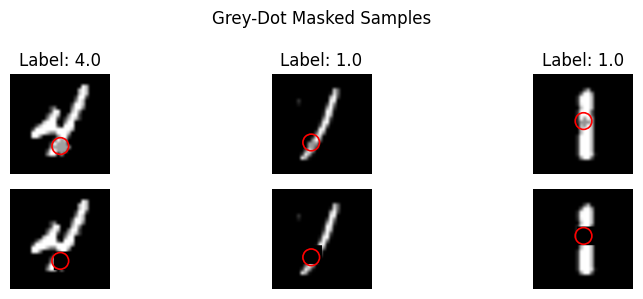

In [11]:
show_sample_with_mask(train_dataset, random_mask_v5_opt1, num_samples=3, patch_size=8, title="Grey-Dot Masked Samples")

In [12]:
import torch.utils.checkpoint as cp

# ----------------------------
# SimpleUNet (lighter / smaller for MNIST)
# ----------------------------
class SimpleUNet(nn.Module):
    """
    Small U-Net for mask-conditioned diffusion on MNIST.
    Input: (image + mask) = 2 channels
    Output: predicted noise for 1 channel
    """
    def __init__(self, in_ch=2, base_ch=32, ch_mults=(1, 2, 2, 2)):
        super().__init__()
        # Encoder
        self.encs = nn.ModuleList()
        self.pools = nn.ModuleList()
        ch = in_ch
        for m in ch_mults:
            out_ch = base_ch * m
            self.encs.append(nn.Sequential(
                nn.Conv2d(ch, out_ch, 3, padding=1),
                nn.GroupNorm(4, out_ch),
                nn.SiLU(),
                nn.Conv2d(out_ch, out_ch, 3, padding=1),
                nn.GroupNorm(4, out_ch),
                nn.SiLU(),
            ))
            self.pools.append(nn.Conv2d(out_ch, out_ch, 3, stride=2, padding=1))
            ch = out_ch

        # Bottleneck
        self.bottleneck = nn.Sequential(
            nn.Conv2d(ch, ch*2, 3, padding=1),
            nn.GroupNorm(4, ch*2),
            nn.SiLU(),
            nn.Conv2d(ch*2, ch, 3, padding=1),
            nn.GroupNorm(4, ch),
            nn.SiLU(),
        )

        # Decoder
        self.decs = nn.ModuleList()
        self.ups = nn.ModuleList()
        for m in reversed(ch_mults):
            out_ch = base_ch * m
            self.ups.append(nn.ConvTranspose2d(ch, out_ch, 4, stride=2, padding=1))
            self.decs.append(nn.Sequential(
                nn.Conv2d(out_ch*2, out_ch, 3, padding=1),
                nn.GroupNorm(4, out_ch),
                nn.SiLU(),
                nn.Conv2d(out_ch, out_ch, 3, padding=1),
                nn.GroupNorm(4, out_ch),
                nn.SiLU(),
            ))
            ch = out_ch

        # Final conv to predict noise
        self.final = nn.Sequential(
            nn.Conv2d(ch, ch, 3, padding=1),
            nn.SiLU(),
            nn.Conv2d(ch, 1, 3, padding=1)
        )

    def forward(self, x):
        skips = []
        h = x
        for enc, pool in zip(self.encs, self.pools):
            h = enc(h)
            skips.append(h)
            h = pool(h)

        h = self.bottleneck(h)

        for up, dec, skip in zip(self.ups, self.decs, reversed(skips)):
            h = up(h)
            if h.shape[-2:] != skip.shape[-2:]:
                _, _, H, W = h.shape
                skip = transforms.functional.center_crop(skip, (H, W))
            h = torch.cat([h, skip], dim=1)
            h = dec(h)

        return self.final(h)

In [13]:
# ----------------------------
# DiffusionModel (with __call__, train/eval support)
# ----------------------------
class DiffusionModel(nn.Module):
    """
    Lightweight DDPM wrapper with train/predict helpers.
    Supports masked reconstruction and AMP training.
    """
    def __init__(
        self,
        denoise_model: nn.Module,
        image_size=28,
        channels=1,
        timesteps=200,
        sample_timesteps=None,
        beta_start=1e-4,
        beta_end=0.02,
        device=device
    ):
        super().__init__()
        self.model = denoise_model.to(device)
        self.image_size = image_size
        self.channels = channels
        self.device = device

        self.T = timesteps
        self.sample_T = sample_timesteps if sample_timesteps is not None else timesteps

        # betas / alphas
        betas = torch.linspace(beta_start, beta_end, self.T, device=device)
        alphas = 1.0 - betas
        alphas_cumprod = torch.cumprod(alphas, dim=0)

        self.register_buffer('betas', betas)
        self.register_buffer('alphas', alphas)
        self.register_buffer('alphas_cumprod', alphas_cumprod)
        self.register_buffer('sqrt_alphas_cumprod', torch.sqrt(alphas_cumprod))
        self.register_buffer('sqrt_one_minus_alphas_cumprod', torch.sqrt(1 - alphas_cumprod))

    def forward(self, x, mask):
        """
        Standard forward: given masked input, predict reconstruction.
        """
        return self.model(torch.cat([x, mask], dim=1))

    # ----------------------------
    # Diffusion functions
    # ----------------------------
    def q_sample(self, x_start, t, noise=None):
        if noise is None:
            noise = torch.randn_like(x_start)
        t = t.to(self.device)
        sqrt_acp = self.sqrt_alphas_cumprod[t].view(-1, 1, 1, 1)
        sqrt_1m_acp = self.sqrt_one_minus_alphas_cumprod[t].view(-1, 1, 1, 1)
        return sqrt_acp * x_start + sqrt_1m_acp * noise

    def p_losses(self, x_start, mask, t, noise=None, mask_weight=5.0):
        if noise is None:
            noise = torch.randn_like(x_start)
        x_noisy = self.q_sample(x_start, t, noise=noise)
        mask_input = mask.to(x_start.device)
        model_in = torch.cat([x_noisy, mask_input], dim=1)
        pred_noise = self.model(model_in)

        masked_regions = 1.0 - mask_input
        visible_regions = mask_input
        if pred_noise.shape[1] != masked_regions.shape[1]:
            masked_regions = masked_regions.expand(-1, pred_noise.shape[1], -1, -1)

        mse = (pred_noise - noise).pow(2)
        loss_masked = (mse * masked_regions).mean()
        loss_visible = (mse * visible_regions).mean()
        loss = mask_weight * loss_masked + loss_visible
        return loss, loss_masked.detach().cpu().item(), loss_visible.detach().cpu().item()

    @torch.no_grad()
    def p_sample(self, x_t, mask, t_index):
        device = self.device
        t = torch.full((x_t.shape[0],), t_index, dtype=torch.long, device=device)
        model_in = torch.cat([x_t, mask.to(device)], dim=1)
        pred_noise = self.model(model_in)

        betas_t = self.betas[t_index]
        alpha_t = self.alphas[t_index]
        alpha_cumprod_t = self.alphas_cumprod[t_index]
        sqrt_one_minus_acp = torch.sqrt(1 - alpha_cumprod_t)

        x0_pred = (x_t - sqrt_one_minus_acp * pred_noise) / torch.sqrt(alpha_cumprod_t)

        if t_index > 0:
            posterior_mean = (
                torch.sqrt(self.alphas_cumprod[t_index - 1]) * betas_t / (1.0 - alpha_cumprod_t) * x0_pred
                + torch.sqrt(alpha_t) * (1.0 - self.alphas_cumprod[t_index - 1]) / (1.0 - alpha_cumprod_t) * x_t
            )
            noise = torch.randn_like(x_t)
            x_prev = posterior_mean + torch.sqrt(betas_t) * noise
        else:
            x_prev = x0_pred
        return x_prev

    @torch.no_grad()
    def sample_with_known(self, known_image, mask, steps=None, progress=False):
        steps = steps or self.sample_T
        device = self.device
        x = torch.randn_like(known_image).to(device)
        for t_index in reversed(range(steps)):
            mapped_t = int(t_index * (self.T / max(1, steps)))
            x = self.p_sample(x, mask, mapped_t)
            x = mask * known_image + (1 - mask) * x
            if progress and t_index % max(1, steps // 10) == 0:
                print(f"Sampling step {t_index}/{steps}")
        return x

    # ----------------------------
    # AMP-aware training step
    # ----------------------------
    def train_step(self, x, mask, optimizer, scaler=None, mask_weight=5.0, use_amp=True):
        self.model.train()
        optimizer.zero_grad()
        t = torch.randint(0, self.T, (x.size(0),), device=self.device).long()

        if use_amp:
            if scaler is None:
                scaler = torch.cuda.amp.GradScaler()
            with torch.cuda.amp.autocast():
                loss, lm, lv = self.p_losses(x, mask, t, mask_weight=mask_weight)
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
        else:
            loss, lm, lv = self.p_losses(x, mask, t, mask_weight=mask_weight)
            loss.backward()
            optimizer.step()

        return loss.item(), lm, lv, scaler if use_amp else None

    def to(self, device_):
        super().to(device_)
        self.device = device_
        return self

    def parameters(self):
        return self.model.parameters()

    def eval(self):
        self.model.eval()

    def train(self, mode=True):
        self.model.train(mode)

    def __call__(self, x, mask):
        return self.forward(x, mask)


In [14]:
# ----------------------------
# Example: instantiate model
# ----------------------------
# Model expects input channels = image channels (1) + mask channel (1) == 2
unet = SimpleUNet(in_ch=1 + 1, base_ch=32, ch_mults=(1, 2, 4))  # smaller base_ch for faster experiments
diffusion = DiffusionModel(unet, image_size=128, channels=1, timesteps=1000, device=device)

# Example training step function you can call inside your loop:
def diffusion_train_step(diffusion: DiffusionModel, optimizer, batch, mask_generator_fn, device=device):
    """
    batch: tuple returned by your DataLoader tuple(out) in InMemoryMNISTDataset 
    
    when return_orig True:
           (image_tensor, label, image_orig, dot_info, idx) depending on flags.
    mask_generator_fn: a function that accepts a batch of original images (PIL->Tensor) and returns
                       masked_image, masks where masks are 1=visible, 0=masked.
    """
    diffusion.model.train()
    optimizer.zero_grad()

    # Unpack your dataset output robustly:
    # Your DataLoader returns (image, label, image_orig, dots, idx) in your config.
    # We prefer to use the returned 'image_orig' as ground-truth x_start (no grey dot).
    items = batch
    # attempt to find original image in tuple (image_orig present because you used return_orig=True)
    # common layouts: (image, label, image_orig, dots, idx) or (image, label)
    # We'll search for a tensor of shape (B,1,128,128)
    x_start = None
    for it in items:
        if isinstance(it, torch.Tensor) and it.ndim == 4 and it.shape[1] == 1:
            # choose the first 1-channel tensor as original image (works for typical ordering)
            if x_start is None:
                x_start = it.to(device)
    if x_start is None:
        raise ValueError("Couldn't locate image tensor (x_start) in batch. Ensure return_orig=True in dataset and transform produces Tensor.")

    # Build mask using your mask function. mask_generator_fn should accept the batch and return (masked_images, masks)
    # For convenience, here's a small wrapper using your random_mask_v5_opt1 which expects image tensor and grey_dot info:
    # NOTE: random_mask_v5_opt1 returns (masked_x, masks) where masks are 0 at masked regions and 1 at visible regions.
    # Make sure masks have shape (B,1,H,W)
    # We'll assume your DataLoader gives dot_info in batch[-2] position; if not, pass grey_dot_coords separately.
    grey_dot_coords = None
    for it in items:
        if isinstance(it, list) or isinstance(it, tuple):
            # skip
            continue
        # detect python list of dicts (dots) from dataset
    # fallback call: generate masks randomly (not ideal) — but user will likely pass the dot info and call random_mask_v5_opt1 externally.

    # Randomly sample time t for each sample
    batch_size = x_start.shape[0]
    t = torch.randint(0, diffusion.T, (batch_size,), device=device).long()

    # generate noise and compute loss
    noise = torch.randn_like(x_start).to(device)
    # For training, we'll create masks using the mask_generator_fn if provided.
    if mask_generator_fn is not None:
        # mask_generator_fn should return masks in the form (masked_x, masks) or (masks,) depending on implementation
        # Here we expect mask_generator_fn(x_start) -> (masked_x, masks)
        masked_x, masks = mask_generator_fn(x_start)
        masks = masks.to(device)
    else:
        # fallback: no mask (all visible)
        masks = torch.ones((batch_size, 1, diffusion.image_size, diffusion.image_size), device=device)

    loss, lm, lv = diffusion.p_losses(x_start, masks, t, noise=noise, mask_weight=8.0)
    loss.backward()
    optimizer.step()
    return loss.item(), lm, lv

# Example optimizer
optimizer = torch.optim.Adam(diffusion.parameters(), lr=1e-4)

In [15]:
# -------------------------------------------------
# Training + Evaluation Function (Diffusion-compatible)
# -------------------------------------------------
def train_and_evaluate(
    diffusion_model, train_loader, val_loader,
    n_epochs=10, mask_ratio=0.3, lr=1e-3,
    patience=10, mask_fn=None, patch_size=None,
    block_size=None,
    show_batch_progress=True
):
    """
    Train a diffusion-based inpainting model with mask weighting and early stopping.
    The diffusion model should expose `.p_losses()` and `.model.parameters()`.
    """
    if mask_fn is None:
        raise ValueError("You must provide a masking function (mask_fn).")

    device = diffusion_model.device
    opt = torch.optim.Adam(diffusion_model.parameters(), lr=lr)

    best_val_loss = float('inf')
    epochs_no_improve = 0
    train_losses, val_losses = [], []

    for epoch in range(n_epochs):
        # -------------------
        # Training
        # -------------------
        diffusion_model.model.train()
        total_train_loss = 0
        epoch_start = time.time()

        train_iter = tqdm(train_loader, desc=f"Epoch {epoch+1}/{n_epochs} - Training", leave=False) \
                     if show_batch_progress else train_loader

        for batch in train_iter:
            # Unpack batch safely
            if len(batch) == 2:
                x, _ = batch
                grey_dot_coords = [None] * x.size(0)
            else:
                x, _, *rest = batch
                grey_dot_coords = [None] * x.size(0)
                if len(rest) > 0 and isinstance(rest[0], (dict, list, tuple)):
                    grey_dot_coords = [rest[0]] + [None] * (x.size(0) - 1)

            x = x.to(device)
            x_masked, mask = mask_fn(
                x,
                grey_dot_coords=grey_dot_coords,
                mask_ratio=mask_ratio,
                patch_size=patch_size,
                block_size=block_size
            )

            # Sample random timesteps for diffusion
            t = torch.randint(0, diffusion_model.T, (x.size(0),), device=device).long()

            # Compute diffusion loss
            loss, masked_loss, visible_loss = diffusion_model.p_losses(x, mask, t)

            opt.zero_grad()
            loss.backward()
            opt.step()

            total_train_loss += loss.item() * x.size(0)
            if show_batch_progress:
                train_iter.set_postfix({"batch_loss": f"{loss.item():.6f}"})

        avg_train_loss = total_train_loss / len(train_loader.dataset)
        train_losses.append(avg_train_loss)

        # -------------------
        # Validation
        # -------------------
        diffusion_model.model.eval()
        total_val_loss = 0

        with torch.no_grad():
            for batch in val_loader:
                if len(batch) == 2:
                    x, _ = batch
                    grey_dot_coords = [None] * x.size(0)
                else:
                    x, _, *rest = batch
                    grey_dot_coords = [None] * x.size(0)
                    if len(rest) > 0 and isinstance(rest[0], (dict, list, tuple)):
                        grey_dot_coords = [rest[0]] + [None] * (x.size(0) - 1)

                x = x.to(device)
                x_masked, mask = mask_fn(
                    x,
                    grey_dot_coords=grey_dot_coords,
                    mask_ratio=mask_ratio,
                    patch_size=patch_size,
                    block_size=block_size
                )

                t = torch.randint(0, diffusion_model.T, (x.size(0),), device=device).long()
                loss, _, _ = diffusion_model.p_losses(x, mask, t)
                total_val_loss += loss.item() * x.size(0)

        avg_val_loss = total_val_loss / len(val_loader.dataset)
        val_losses.append(avg_val_loss)

        epoch_time = time.time() - epoch_start
        print(f"Epoch {epoch+1}/{n_epochs} | "
              f"Train Loss: {avg_train_loss:.6f} | "
              f"Val Loss: {avg_val_loss:.6f} | "
              f"Time: {epoch_time:.1f}s")

        # -------------------
        # Early stopping
        # -------------------
        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1
            if epochs_no_improve >= patience:
                print(f"Early stopping at epoch {epoch+1}")
                break

    return best_val_loss, train_losses, val_losses


=== Training | mask_fn=random_mask_v5_opt1, epochs=15, mask=0.2, lr=0.001, patch_size=8, block_size=5 ===


Epoch 1/15 | Train Loss: 0.018602 | Val Loss: 0.006641 | Time: 169.7s


Epoch 2/15 | Train Loss: 0.005851 | Val Loss: 0.004976 | Time: 151.9s


Epoch 3/15 | Train Loss: 0.004837 | Val Loss: 0.004335 | Time: 153.1s


Epoch 4/15 | Train Loss: 0.004226 | Val Loss: 0.003780 | Time: 156.8s


...

Epoch 11/15 | Train Loss: 0.003563 | Val Loss: 0.003281 | Time: 158.2s


Epoch 12/15 | Train Loss: 0.003366 | Val Loss: 0.003294 | Time: 155.2s


Epoch 13/15 | Train Loss: 0.003388 | Val Loss: 0.003158 | Time: 160.0s


Epoch 14/15 | Train Loss: 0.003273 | Val Loss: 0.003250 | Time: 156.2s


Epoch 15/15 | Train Loss: 0.003291 | Val Loss: 0.003176 | Time: 154.4s
Time for this run: 2360.77 seconds
Test MSE: 0.583175


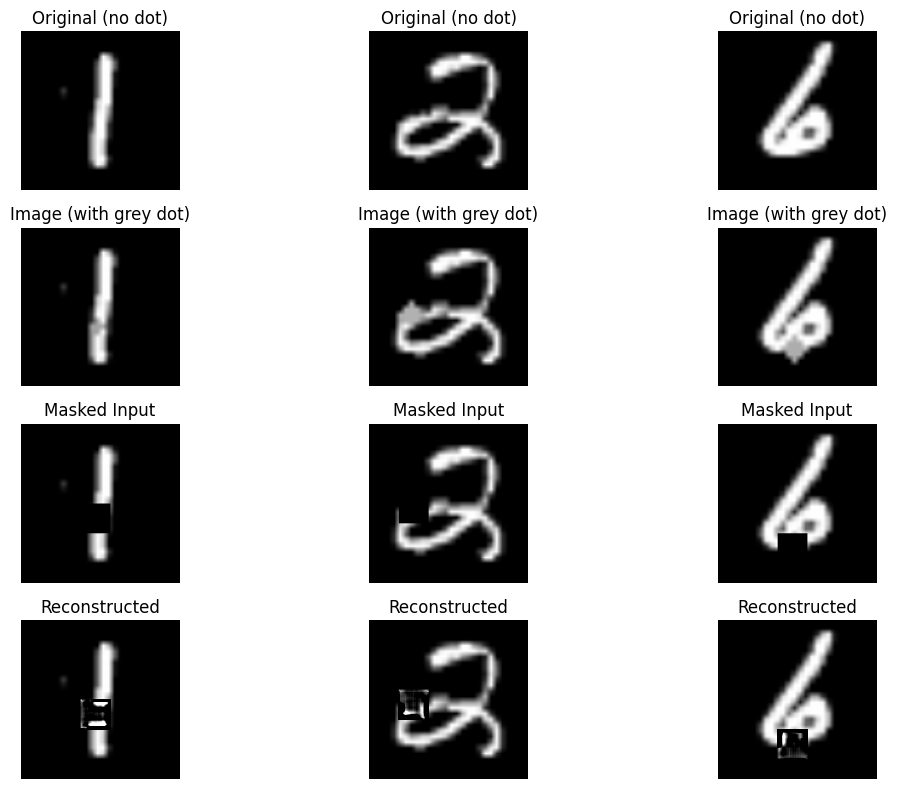


=== Training | mask_fn=random_mask_v5_opt1, epochs=15, mask=0.2, lr=0.001, patch_size=8, block_size=7 ===


Epoch 1/15 | Train Loss: 0.018824 | Val Loss: 0.006680 | Time: 155.6s


Epoch 2/15 | Train Loss: 0.005807 | Val Loss: 0.004646 | Time: 157.6s


Epoch 3/15 | Train Loss: 0.004756 | Val Loss: 0.004497 | Time: 154.6s


Epoch 4/15 | Train Loss: 0.004501 | Val Loss: 0.003832 | Time: 155.0s


...

Epoch 11/15 | Train Loss: 0.003529 | Val Loss: 0.003452 | Time: 153.2s


Epoch 12/15 | Train Loss: 0.003424 | Val Loss: 0.003451 | Time: 153.5s


Epoch 13/15 | Train Loss: 0.003315 | Val Loss: 0.003469 | Time: 156.5s


Epoch 14/15 | Train Loss: 0.003359 | Val Loss: 0.003438 | Time: 154.5s


Epoch 15/15 | Train Loss: 0.003317 | Val Loss: 0.003283 | Time: 152.7s
Time for this run: 2362.49 seconds
Test MSE: 0.478259


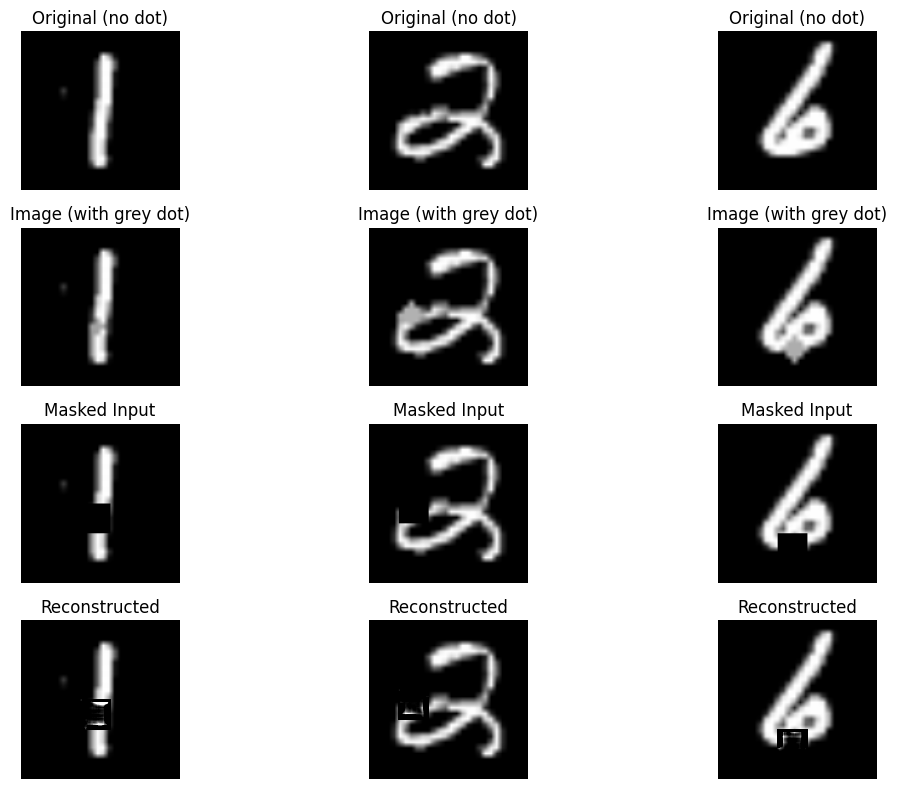

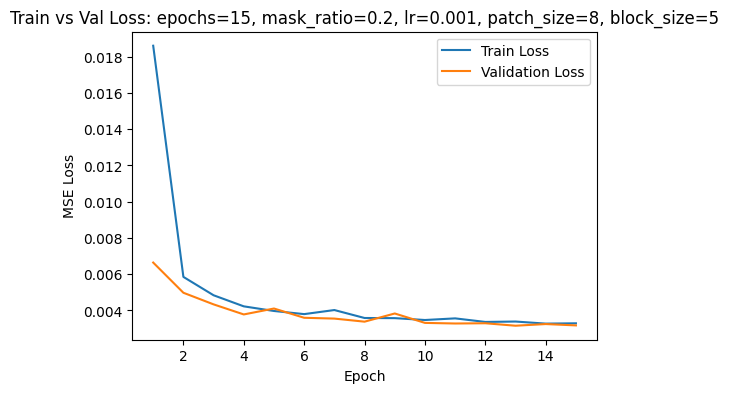

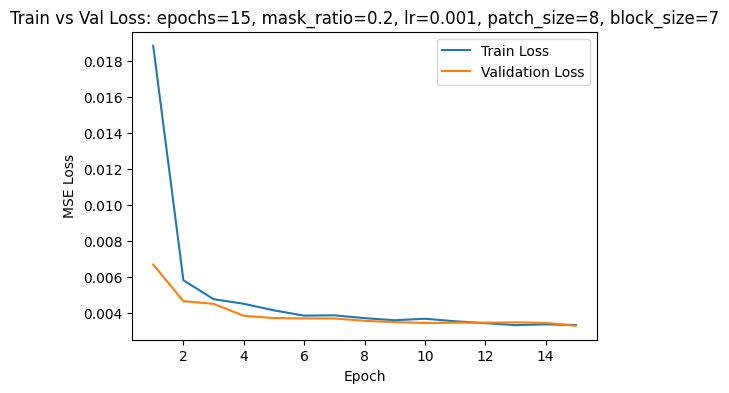

In [16]:

# ======================================================
# Hyperparameter Sweep (compatible with new DiffusionModel + SimpleUNet)
# ======================================================
epoch_options      = [15]       # Number of training epochs
mask_options       = [0.2]     # Mask ratios
lr_options         = [1e-3]    # Learning rate
patch_size_options = [8]    # Patch sizes
block_size_options = [5,7]    # Block sizes

mask_fn_options = [
    ("random_mask_v5_opt1", random_mask_v5_opt1),
]

results = []
train_val_curves = []

def extract_batch_with_orig(batch):
    """
    Return:
      x: tensor (B, C, H, W) — the dataset image (with grey dot present)
      x_orig: tensor or None (B, C, H, W) — original image without dot if available
      grey_dot_coords: list of dicts or None per item
    """
    # --- same implementation as before ---
    if len(batch) == 2:
        x, _ = batch
        x_orig = None
        grey_dot_coords = [None] * x.size(0)
    else:
        x = batch[0]
        x_orig, dot_info = None, None
        if len(batch) >= 3:
            third = batch[2]
            if isinstance(third, (torch.Tensor, np.ndarray, Image.Image)):
                x_orig = third
            elif isinstance(third, dict) or isinstance(third, (list, tuple)):
                dot_info = third
        if len(batch) >= 4:
            fourth = batch[3]
            if x_orig is None and isinstance(fourth, (torch.Tensor, np.ndarray, Image.Image)):
                x_orig = fourth
            elif dot_info is None and (isinstance(fourth, dict) or isinstance(fourth, (list, tuple))):
                dot_info = fourth

        B = x.size(0)
        if dot_info is None:
            grey_dot_coords = [None] * B
        elif isinstance(dot_info, dict) and all(isinstance(dot_info.get(k), torch.Tensor) for k in ("y", "x")):
            n = dot_info["y"].numel()
            grey_dot_coords = [
                {
                    "y": int(dot_info["y"][i].item()),
                    "x": int(dot_info["x"][i].item()),
                    "radius": int(dot_info.get("radius", torch.tensor(1))[i].item()) if "radius" in dot_info else 1
                }
                for i in range(n)
            ]
            if len(grey_dot_coords) < B:
                grey_dot_coords += [None] * (B - len(grey_dot_coords))
        elif isinstance(dot_info, (list, tuple)):
            grey_dot_coords = [di if isinstance(di, dict) else None for di in dot_info]
            if len(grey_dot_coords) < B:
                grey_dot_coords += [None] * (B - len(grey_dot_coords))
        else:
            grey_dot_coords = [dot_info] + [None] * (B - 1) if isinstance(dot_info, dict) else [None] * B

        if x_orig is not None and isinstance(x_orig, torch.Tensor) and x_orig.shape[0] != x.shape[0]:
            try:
                x_orig = x_orig.repeat(x.shape[0], *([1] * (x_orig.dim() - 1)))
            except:
                x_orig = None

    return x, x_orig, grey_dot_coords


# ======================================================
# Main training + evaluation sweep
# ======================================================
for mask_fn_name, mask_fn in mask_fn_options:
    for n_epoch in epoch_options:
        for mask_ratio in mask_options:
            for lr in lr_options:
                for patch_size in patch_size_options:
                    for block_size in block_size_options:

                        print("\n" + "="*60)
                        print(f"=== Training | mask_fn={mask_fn_name}, epochs={n_epoch}, "
                              f"mask={mask_ratio}, lr={lr}, patch_size={patch_size}, block_size={block_size} ===")

                        start_time = time.time()

                        model_copy = DiffusionModel(
                            denoise_model=SimpleUNet(in_ch=2),
                            image_size=128,
                            timesteps=200,
                            device=device
                        )

                        best_val_loss, train_losses, val_losses = train_and_evaluate(
                            model_copy,
                            train_loader, val_loader,
                            n_epochs=n_epoch,
                            mask_ratio=mask_ratio,
                            lr=lr,
                            patience=10,
                            mask_fn=mask_fn,
                            patch_size=patch_size,
                            block_size=block_size
                        )

                        # -------------------------------------------------
                        # Test set evaluation
                        # -------------------------------------------------
                        model_copy.eval()
                        mse_loss = nn.MSELoss()
                        test_mse = 0.0
                        with torch.no_grad():
                            for batch in test_loader:
                                x, x_orig, grey_dot_coords = extract_batch_with_orig(batch)
                                x = x.to(device)
                                x_masked, mask = mask_fn(
                                    x,
                                    grey_dot_coords=grey_dot_coords,
                                    mask_ratio=mask_ratio,
                                    patch_size=patch_size,
                                    block_size=block_size
                                )
                                x_rec = model_copy(x_masked, mask)
                                loss = mse_loss(x_rec * mask, x * mask)
                                test_mse += loss.item() * x.size(0)

                        test_mse /= len(test_loader.dataset)
                        elapsed = time.time() - start_time

                        print(f"Time for this run: {elapsed:.2f} seconds")
                        print(f"Test MSE: {test_mse:.6f}")

                        # Store results
                        results.append({
                            "mask_fn": mask_fn_name,
                            "epochs": n_epoch,
                            "mask_ratio": mask_ratio,
                            "lr": lr,
                            "patch_size": patch_size,
                            "block_size": block_size,
                            "val_loss": best_val_loss,
                            "test_mse": test_mse,
                            "train_time_s": elapsed
                        })

                        train_val_curves.append({
                            "config": (mask_fn_name, n_epoch, mask_ratio, lr, patch_size, block_size),
                            "train_losses": train_losses,
                            "val_losses": val_losses
                        })

                        # -------------------------------------------------
                        # Example reconstructions
                        # -------------------------------------------------
                        with torch.no_grad():
                            batch = next(iter(test_loader))
                            x, x_orig, grey_dot_coords = extract_batch_with_orig(batch)
                            x = x.to(device)
                            x_orig_t = x_orig.to(device) if x_orig is not None else None
                            x_masked, mask = mask_fn(x, grey_dot_coords, mask_ratio=mask_ratio, patch_size=patch_size)
                            x_rec = model_copy(x_masked, mask)

                        n_show = 3
                        plt.figure(figsize=(12,8))
                        for i in range(n_show):
                            orig_np = x_orig_t[i,0].cpu().numpy() if x_orig_t is not None else x[i,0].cpu().numpy()
                            img_with_dot_np = x[i,0].cpu().numpy()
                            masked_np = x_masked[i,0].cpu().numpy()
                            rec_np = x_rec[i,0].cpu().numpy()
                            mask_np = (mask[i,0].cpu().numpy() > 0.5).astype(np.float32)
                            filled = masked_np * mask_np + rec_np * (1.0 - mask_np)

                            plt.subplot(4,n_show,i+1)
                            plt.imshow(orig_np, cmap='gray', vmin=0,vmax=1)
                            plt.title("Original (no dot)"); plt.axis('off')

                            plt.subplot(4,n_show,i+1+n_show)
                            plt.imshow(img_with_dot_np, cmap='gray', vmin=0,vmax=1)
                            plt.title("Image (with grey dot)"); plt.axis('off')

                            plt.subplot(4,n_show,i+1+2*n_show)
                            plt.imshow(masked_np, cmap='gray', vmin=0,vmax=1)
                            plt.title("Masked Input"); plt.axis('off')

                            plt.subplot(4,n_show,i+1+3*n_show)
                            plt.imshow(filled, cmap='gray', vmin=0,vmax=1)
                            plt.title("Reconstructed"); plt.axis('off')

                        plt.tight_layout()
                        plt.show()

# ======================================================
# Results summary and plots
# ======================================================
df_val = pd.DataFrame(results)


for curve in train_val_curves:
    config = curve["config"]
    train_losses = curve["train_losses"]
    val_losses = curve["val_losses"]
    mask_fn_name, n_epoch, mask_ratio, lr, patch_size, block_size = config

    plt.figure(figsize=(6, 4))
    plt.plot(range(1, len(train_losses) + 1), train_losses, label="Train Loss")
    plt.plot(range(1, len(val_losses) + 1), val_losses, label="Validation Loss")
    plt.title(f"Train vs Val Loss: epochs={n_epoch}, mask_ratio={mask_ratio}, lr={lr}, patch_size={patch_size}, block_size={block_size}")
    plt.xlabel("Epoch")
    plt.ylabel("MSE Loss")
    plt.legend()
    plt.show()


In [17]:
# -------------------------------------------------
# Evaluation & Visualization (Diffusion Model)
# -------------------------------------------------
def evaluate_and_visualize(diffusion_model, test_loader, mask_fn, mask_ratio, patch_size, block_size, device, num_images=8):
    diffusion_model.model.eval()
    all_mse = []

    originals, masked_imgs, reconstructions = [], [], []

    with torch.no_grad():
        for batch in tqdm(test_loader, desc="Evaluating"):
            if len(batch) == 2:
                x, _ = batch
                grey_dot_coords = [None] * x.size(0)
            else:
                x, _, *rest = batch
                grey_dot_coords = [None] * x.size(0)
                if len(rest) > 0 and isinstance(rest[0], (dict, list, tuple)):
                    grey_dot_coords = [rest[0]] + [None] * (x.size(0) - 1)

            x = x.to(device)
            x_masked, mask = mask_fn(
                x,
                grey_dot_coords=grey_dot_coords,
                mask_ratio=mask_ratio,
                patch_size=patch_size,
                block_size=block_size
            )

            # Use diffusion to reconstruct masked regions
            x_recon = diffusion_model.sample_with_known(x_masked, mask, steps=100)

            mse = ((x_recon - x) ** 2).mean(dim=[1, 2, 3])
            all_mse.extend(mse.cpu().numpy())

            # Collect a few samples for display
            if len(originals) < num_images:
                originals.append(x.cpu())
                masked_imgs.append(x_masked.cpu())
                reconstructions.append(x_recon.cpu())

            # Only evaluate a few batches if just for display
            if len(originals) >= num_images:
                break

    avg_mse = np.mean(all_mse)
    print(f"\nTest MSE: {avg_mse:.6f}")

    # -----------------------------
    # Visualization Grid
    # -----------------------------
    originals = torch.cat(originals, dim=0)[:num_images]
    masked_imgs = torch.cat(masked_imgs, dim=0)[:num_images]
    reconstructions = torch.cat(reconstructions, dim=0)[:num_images]

    fig, axes = plt.subplots(3, num_images, figsize=(num_images * 2, 6))
    for i in range(num_images):
        axes[0, i].imshow(originals[i].squeeze(), cmap='gray')
        axes[1, i].imshow(masked_imgs[i].squeeze(), cmap='gray')
        axes[2, i].imshow(reconstructions[i].squeeze(), cmap='gray')
        for j in range(3):
            axes[j, i].axis('off')

    axes[0, 0].set_ylabel("Original", fontsize=12)
    axes[1, 0].set_ylabel("Masked", fontsize=12)
    axes[2, 0].set_ylabel("Reconstructed", fontsize=12)
    plt.tight_layout()
    plt.show()

    return avg_mse


Evaluating:   3%|▎         | 7/263 [00:28<17:33,  4.12s/it]



Test MSE: 0.001006


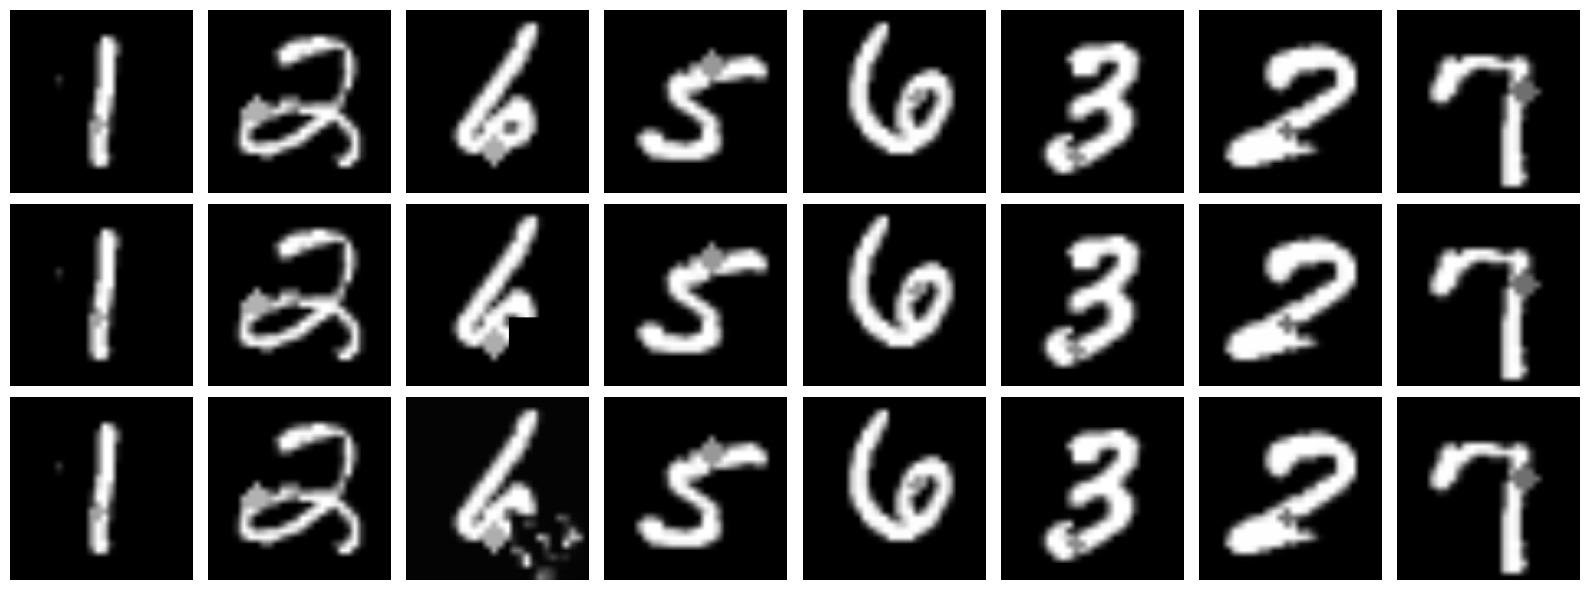

In [18]:
test_mse = evaluate_and_visualize(
    diffusion_model=model_copy,
    test_loader=test_loader,
    mask_fn=random_mask_v5_opt1,
    mask_ratio=mask_ratio,
    patch_size=patch_size,
    block_size=block_size,
    device=device,
    num_images=8
)